In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Number of CUDA devices:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Current CUDA device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    print("No GPU (CUDA) available. Running on CPU.")

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
Number of CUDA devices: 1
Current CUDA device: 0
Device name: NVIDIA GeForce RTX 5060 Laptop GPU


In [2]:
## read data
import numpy as np

results = np.load('river1.npy', allow_pickle=True).item()

centerline_points = results['centerline']
smooth_cross_sections = results['cross_sections']
velocity_distributions = results['velocity_distributions']

print("Number of centerline points:", len(centerline_points))
print("Number of cross-sections:", len(smooth_cross_sections))
print("Number of velocity distribution data points:", len(velocity_distributions))

# Example: Accessing the velocity distribution of the first cross-section
first_section_velocity = velocity_distributions[0]['velocities']
B =  velocity_distributions[0]['Bottom width']
H_of_water =  velocity_distributions[0]['Hofwater']
print("Width of the first cross-section:", B)
print("Velocity distribution of the first cross-section:", first_section_velocity)
print("Water depth distribution of the first cross-section:", H_of_water)


Number of centerline points: 875
Number of cross-sections: 35
Number of velocity distribution data points: 35
Width of the first cross-section: 6.929646455628166
Velocity distribution of the first cross-section: [0.         0.22578669 0.28742988 0.33802343 0.36965837 0.40014972
 0.41340492 0.42412645 0.43366614 0.44224868 0.45008912 0.45632534
 0.46249832 0.46663226 0.46849947 0.47003299 0.47019815 0.47031719
 0.47270433 0.47479884 0.4751345  0.48109815 0.4871966  0.49039076
 0.49196444 0.49369735 0.49680541 0.50020736 0.50210022 0.50265401
 0.50158126 0.49909755 0.49542544 0.49095615 0.48553185 0.4808981
 0.47622306 0.47184253 0.46929278 0.46589575 0.46188739 0.45598164
 0.44452563 0.42246436 0.39761684 0.34250601 0.27816238 0.21445984
 0.        ]
Water depth distribution of the first cross-section: [0.         0.12502523 0.23218097 0.26828265 0.29958216 0.32505532
 0.33833647 0.3450311  0.35008409 0.35619533 0.35918978 0.36569374
 0.37212753 0.3758488  0.37568209 0.37423575 0.370832

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d

def correct_velocity_rozos(
    Ux,
    n: int = 5,
    uncertainty: float = 0.20,
    corr_length: float = 0.30,
    ia_skew: float = 0.10,
    bias_scale: float = 0.03,
    xcorr_low_vel_frac: float = 0.10,
    ci: float = 0.90,
    seed: int | None = None,
) -> dict:
    """
    Rozos et al. (2020) Monte Carlo mean correction.

    Principle
    ----
    Generate n samples from triangular distributions for three parameters 
    (contrast adjustment, minimum cross-correlation, IA size), take the 
    n³ Cartesian product, apply the corresponding perturbations to each 
    combination, and use the 90% CI mean profile as the corrected optimal 
    estimate.

    Parameters
    ----------
    Ux          : Original (or single-shot noise) velocity profile, length N.
    n           : Number of samples per parameter, total runs = n³.
                  Rozos suggests n=5 (125 runs) is sufficient for convergence.
    uncertainty : Total uncertainty (corresponding to 90% CI half-width), default 0.20.
    corr_length : Spatial correlation length of IA perturbations (relative to section length).
    ia_skew     : IA skewness strength (biased toward large IA → underestimation).
    bias_scale  : Global bias magnitude from contrast adjustment.
    xcorr_low_vel_frac : Additional error magnitude for pseudo-vectors in low-velocity regions.
    ci          : Confidence interval width, default 0.90 (90% CI).
    seed        : Random seed.

    Returns
    -------
    dict with keys:
        'mean'   : Mean profile (corrected optimal estimate, corresponds to Rozos mean profile)
        'lower'  : Lower CI bound
        'upper'  : Upper CI bound
        'ci_width': Pointwise confidence interval width (can be used to infer optimal L, see Section 3 of the paper)
        'all_profiles' : shape (n³, N) all MC profiles
    """
    Ux = np.asarray(Ux, dtype=float)
    N = len(Ux)
    rng = np.random.default_rng(seed)

    alpha_lo = (1.0 - ci) / 2.0   # 0.05
    alpha_hi = 1.0 - alpha_lo      # 0.95

    # ── Generate n triangular distribution samples for three parameters ──
    # Parameter 1: Contrast adjustment Tri(0.3, 0.9, 0.7) → global bias factor
    p_contrast = rng.triangular(0.3, 0.7, 0.9, size=n)       # shape (n,)
    bias_vals  = ((p_contrast - 0.6) / 0.3) * bias_scale     # ∈ [-bias_scale, +bias_scale]

    # Parameter 2: Minimum cross-correlation Tri(0.3, 0.9, 0.6) → pseudo-vector strength in low-velocity regions
    p_xcorr    = rng.triangular(0.3, 0.6, 0.9, size=n)
    xcorr_vals = ((p_xcorr - 0.6) / 0.3) * xcorr_low_vel_frac

    # Parameter 3: IA size Tri(0.5L, 2L, L) → spatial correlation length scale
    p_ia       = rng.triangular(0.5, 1.0, 2.0, size=n)       # relative to L
    corr_vals  = p_ia * corr_length                           # actual correlation length

    # ── n³ Cartesian product, apply perturbations per combination ──
    profiles = np.empty((n ** 3, N), dtype=float)
    vel_threshold = np.percentile(np.abs(Ux), 25)
    low_mask = np.abs(Ux) < vel_threshold

    idx = 0
    for b in bias_vals:
        for xc in xcorr_vals:
            for cl in corr_vals:
                # --- IA perturbation: spatially correlated multiplicative noise ---
                raw_ia = rng.standard_normal(N)
                sigma_px = max(cl * N, 0.5)
                ia_noise = gaussian_filter1d(raw_ia, sigma=sigma_px)
                ia_noise = ia_noise / (ia_noise.std() + 1e-12) * (uncertainty / 3.0)
                # Apply ia_skew (biased toward underestimation)
                ia_noise -= ia_skew * (uncertainty / 3.0)
                noise_ia = 1.0 + ia_noise

                # --- Contrast bias: global bias across the entire section ---
                noise_contrast = 1.0 + b

                # --- Low cross-correlation pseudo-vectors: only in low-velocity regions ---
                noise_xcorr = np.ones(N)
                if low_mask.any():
                    noise_xcorr[low_mask] = 1.0 + (
                        rng.uniform(-1, 1, int(low_mask.sum())) * abs(xc)
                    )

                profiles[idx] = Ux * noise_ia * noise_contrast * noise_xcorr
                idx += 1

    # ── Take CI mean profile (Rozos: mean of confidence interval) ──
    lower  = np.quantile(profiles, alpha_lo, axis=0)
    upper  = np.quantile(profiles, alpha_hi, axis=0)
    mean   = profiles.mean(axis=0)

    return {
        'mean'        : mean,
        'lower'       : lower,
        'upper'       : upper,
        'ci_width'    : upper - lower,
        'all_profiles': profiles,
    }

def smooth_velocity(Ux_noisy, method='savgol', window=7, polyorder=3, sigma=2):
    """
    Smooth noisy velocity to reduce inflection points.
    
    Parameters:
    - method: 'savgol'  → Savitzky-Golay local polynomial least squares (recommended)
              'gaussian' → Gaussian kernel convolution (isotropic smoothing)
              'moving'   → Moving average (simplest)
    - window    : Sliding window length (must be odd)
    - polyorder : Polynomial order for SG filter (window > polyorder)
    - sigma     : Gaussian kernel standard deviation (controls smoothing strength)
    
    Mathematical principle:
    - Savitzky-Golay: Fit a k-th order polynomial using least squares within each window, 
                      preserving peak shapes without losing extrema.
    - Gaussian: y_smooth[i] = Σ G(j)·y[i+j], G~N(0,σ²)
    - Moving Average: y_smooth[i] = mean(y[i-w:i+w])
    """
    if method == 'savgol':
        # window must be <= len(Ux_noisy) and odd
        win = min(window, len(Ux_noisy) if len(Ux_noisy) % 2 != 0
                  else len(Ux_noisy) - 1)
        return savgol_filter(Ux_noisy, window_length=win, polyorder=polyorder)

    elif method == 'gaussian':
        return gaussian_filter1d(Ux_noisy, sigma=sigma)

    elif method == 'moving':
        kernel = np.ones(window) / window
        # 'same' keeps length unchanged; edge reflection is used for padding
        return np.convolve(
            np.pad(Ux_noisy, window // 2, mode='reflect'),
            kernel, mode='valid'
        )[:len(Ux_noisy)]

    else:
        raise ValueError("method must be 'savgol' | 'gaussian' | 'moving'")

/tmp/ipykernel_39878/3347194911.py:3: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.signal import savgol_filter


In [4]:
import torch
from scipy.interpolate import interp1d

def load_array(data_arrays, batch_size, is_train=False):  #@save

    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

def fun_calDiff(data, y, num_points=50):
    if len(data) != len(y):
        raise ValueError("data and y must have the same length")
    
    indices = np.linspace(0, len(data) - 1, num_points)

    interp_data = interp1d(np.arange(len(data)), data, kind='linear', fill_value="extrapolate")
    interp_y = interp1d(np.arange(len(y)), y, kind='linear', fill_value="extrapolate")
    data = interp_data(indices)
    y = interp_y(indices)

    U_avi, U_diff, Y_diff = [], [], []

    for i in range(len(data) - 1):
        if y[i + 1] == y[i]:
            raise ValueError("y[i+1] - y[i] is zero, cannot divide by zero")
            # return 100
        U_avi.append((data[i + 1] + data[i]) / 2)
        U_diff.append(abs((data[i + 1] - data[i])) / abs(y[i + 1] - y[i]))
        Y_diff.append(abs(y[i + 1] - y[i]))

    return U_avi, U_diff, Y_diff

def PredSplitData(data0,num_points=50,alpha=0.8, add_uncertainty=False, uncertainty=0.2, noisy = 'mean'):
    B0 = data0[int(len(data0)-1)]
    dsize = int((len(data0)-1)/2.0)
    Ux0 = data0[0:dsize] / alpha

    # 如果请求，则添加速度不确定性
    if add_uncertainty:
        # Ux0 = add_velocity_uncertainty_rozos(Ux0, uncertainty=0.20, seed=0)
        result = correct_velocity_rozos(
            Ux0, n=5, 
            uncertainty=0.20, 
            ia_skew=0.15,
            bias_scale=0.05,
            xcorr_low_vel_frac=0.15,
            corr_length=0.20,
            ci = 0.9,
            seed=54,)
        # seed=43,44,47,48,53
        Ux_noisy_new_mean = result['mean']
        Ux_noisy_new_lower = result['lower']
        Ux_noisy_new_upper = result['upper']
        if noisy == 'mean':
            Ux0 = smooth_velocity(Ux_noisy_new_mean, method='savgol', window=7, polyorder=3)
        if noisy == 'lower':
            Ux0 = smooth_velocity(Ux_noisy_new_lower, method='savgol', window=7, polyorder=3)
        if noisy == 'upper':
            Ux0 = smooth_velocity(Ux_noisy_new_upper, method='savgol', window=7, polyorder=3)

    Y = data0[dsize:2*dsize]
    # inValueU = Ux0

## Data Grade Enhance————
    max_index = np.argmax(Ux0)
    Bleft = B0* (max_index + 1)/len(Ux0)
    Bright = B0-Bleft
    Uint = Ux0[:max_index + 1]
    Yint = Y[:max_index + 1]
    U_avi,U_diff,Y_diff = fun_calDiff(Uint,Yint)
##——————————————————————————————————————

    pin_np1 = np.array(U_avi).reshape(1,-1)
    pin_np2 = np.array(U_diff).reshape(1,-1)
    pin_np3 = np.array(Y_diff).reshape(1,-1)
    pin_npleft = np.vstack((pin_np1, pin_np2, pin_np3))

    Uint = Ux0[max_index:]
    Uint = Uint[::-1]
    Yint = Y[max_index:]
    Yint = Yint[::-1]
    U_avi,U_diff,Y_diff = fun_calDiff(Uint,Yint,num_points=num_points)
    pin_np1 = np.array(U_avi).reshape(1,-1)
    pin_np2 = np.array(U_diff).reshape(1,-1)
    pin_np3 = np.array(Y_diff).reshape(1,-1)
    pin_npright = np.vstack((pin_np1, pin_np2, pin_np3))

    return pin_npleft, pin_npright,Bleft,Bright

def genFeaturesAndB(data_set,num_points=50,alpha=0.8,add_uncertainty=False, noisy = 'mean'):
    featurel,featurer,Bl,Br=[],[],[],[]
    for data0 in data_set:
        pin_npleft, pin_npright,Bleft,Bright =PredSplitData(data0,num_points=num_points,alpha=alpha,add_uncertainty=add_uncertainty, noisy = noisy)
        featurel.append(pin_npleft)
        Bl.append(Bleft)
        featurer.append(pin_npright)
        Br.append(Bright)
    featuresl =  torch.from_numpy(np.array(featurel))
    featuresr =  torch.from_numpy(np.array(featurer))
    BL = torch.from_numpy(np.array(Bl))
    BR = torch.from_numpy(np.array(Br))
    return featuresl, featuresr, BL, BR

def realprediction(data_iter,net,cuda=False,l=0,r=0):
    Q_pred,H_pred,V_pred=[],[],[]
    if l==1:
        for featuresl, featuresr, BL, BR in data_iter:
            pin_np= featuresl
            pin = torch.from_numpy(np.float32(pin_np))
            pin.requires_grad = False
            if cuda:
                pred = net(pin.cuda())
            else:
                pred = net(pin.cpu())  
            UH_preds = pred.detach().cpu().numpy()
            for UH_pred,b in zip(UH_preds,BL):
                Q0_pred = UH_pred[0]*UH_pred[1]*b
                Q_pred.append(Q0_pred) 
                V0_pred = UH_pred[0]
                V_pred.append(V0_pred)
                H0_pred = UH_pred[1]
                H_pred.append(H0_pred)
    if r==1:        
        for featuresl, featuresr, BL, BR in data_iter:
            pin_np= featuresr
            pin = torch.from_numpy(np.float32(pin_np))
            pin.requires_grad = False
            if cuda:
                pred = net(pin.cuda())
            else:
                pred = net(pin.cpu())  
            UH_preds = pred.detach().cpu().numpy()
            for UH_pred,b in zip(UH_preds,BR):
                Q0_pred = UH_pred[0]*UH_pred[1]*b
                Q_pred.append(Q0_pred) 
                V0_pred = UH_pred[0]
                V_pred.append(V0_pred)
                H0_pred = UH_pred[1]
                H_pred.append(H0_pred)
    if l+r ==2:
        print('error,l&r==!2')
    if l+r==0:
        print('not defiend l&r')

    return Q_pred, V_pred, H_pred

In [5]:
def plotrealriver_alpha(Q_pred, Q_pred_alpha, Qx, V_pred, V_pred_alpha, Vx, H_pred, H_pred_alpha, Hx):

    from sklearn.metrics import mean_squared_error, r2_score
    metrics, metrics_alpha = {},{}
    for name, pred, true in [('Q', Q_pred, Qx), ('V', V_pred, Vx), ('H', H_pred, Hx)]:
        mse = mean_squared_error(true, pred)
        r2 = r2_score(true, pred)
        metrics[name] = {'MSE': mse, 'R²': r2}
    for name, pred, true in [('Q', Q_pred_alpha, Qx), ('V', V_pred_alpha, Vx), ('H', H_pred_alpha, Hx)]:
        mse = mean_squared_error(true, pred)
        r2 = r2_score(true, pred)
        metrics_alpha[name] = {'MSE': mse, 'R²': r2}

    plt.rcParams.update({'font.size': 18})
    plt.rcParams['font.family'] = 'Times New Roman'
    # plt.rcParams['font.family'] = 'TimesSimSun'
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.rm'] = 'Times New Roman'
    plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
    plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
    
    fig = plt.figure(figsize=(10.3, 8))
    plt.subplots_adjust(top=0.85)
    
    ax2 = plt.subplot(2, 1, 1)
    
    ax2.plot(V_pred, label=r'Predicted (Noise_mean)', color='blue', linewidth=1.5, linestyle='--')
    
    ax2.plot(V_pred_alpha, label=r'Predicted (original data)', color='blue', linewidth=2)
    ax2.plot(Vx, label='Measured (Masafu et al., 2022)', color='red', linewidth=2)

    # ax2.set_title('Cross-sectional Average Velocity ($V$)', fontsize=20, pad=15)
    # ax2.set_xlabel('Cross sections', fontsize=20)
    ax2.set_ylabel(r'$V$ (m/s)', fontsize=20)
    
    handles, labels = ax2.get_legend_handles_labels()
    
    ordered_handles = [handles[1], handles[0], handles[2]]
    ordered_labels = [labels[1], labels[0], labels[2]]
    
    legend1 = ax2.legend([ordered_handles[0], ordered_handles[1]], 
                        [ordered_labels[0], ordered_labels[1]], 
                        loc='upper left', bbox_to_anchor=(0.001, 1.02), 
                        ncol=2, frameon=False, fontsize=18)
    ax2.add_artist(legend1)
    
    legend2 = ax2.legend([ordered_handles[2]], [ordered_labels[2]], 
                        loc='upper left', bbox_to_anchor=(0.001, 0.87), 
                        ncol=1, frameon=False, fontsize=18)
    
    y_min = min(min(V_pred), min(Vx), min(V_pred_alpha))
    y_max = max(max(V_pred), max(Vx), max(V_pred_alpha))
    ax2.set_ylim(y_min - 0.12, y_max + 0.3)  

    ax3 = plt.subplot(2, 1, 2)
    ax3.plot(H_pred, label=r'Predicted (Noise_mean)', color='blue', linewidth=1.5, linestyle='--')
    ax3.plot(H_pred_alpha, label=r'Predicted (original data)', color='blue', linewidth=2)
    ax3.plot(Hx, label='Measured (Masafu et al., 2022)', color='red', linewidth=2)
    ax3.set_xlabel('Cross Sections', fontsize=20)
    ax3.set_ylabel(r'$H$ (m)', fontsize=20)
    
    handles, labels = ax3.get_legend_handles_labels()
    ordered_handles = [handles[1], handles[0], handles[2]]
    ordered_labels = [labels[1], labels[0], labels[2]]
    
    legend3 = ax3.legend([ordered_handles[0], ordered_handles[1]], 
                        [ordered_labels[0], ordered_labels[1]], 
                        loc='upper left', bbox_to_anchor=(0.001, 1.02), 
                        ncol=2, frameon=False, fontsize=18)
    ax3.add_artist(legend3)
    
    legend4 = ax3.legend([ordered_handles[2]], [ordered_labels[2]], 
                        loc='upper left', bbox_to_anchor=(0.001, 0.87), 
                        ncol=1, frameon=False, fontsize=18)
    
    y_min = min(min(H_pred), min(Hx), min(H_pred_alpha))
    y_max = max(max(H_pred), max(Hx), max(H_pred_alpha))
    ax3.set_ylim(y_min - 0.12 , y_max + 0.35)  

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, top=0.85)
    plt.show()
    
    return metrics , metrics_alpha


findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


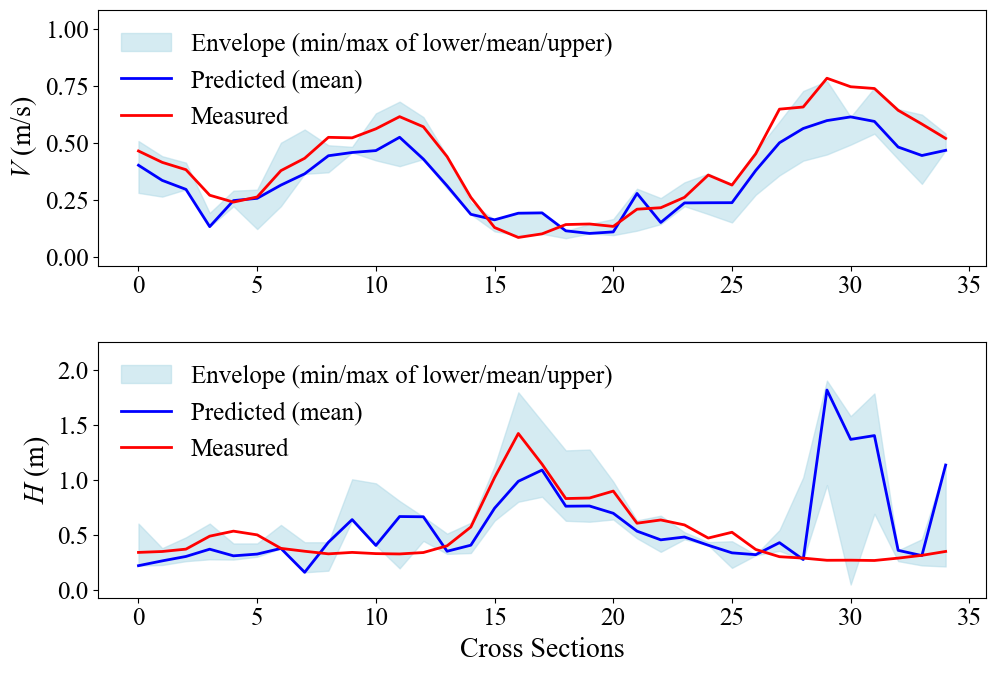

<Figure size 640x480 with 0 Axes>

In [7]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import sys
from pathlib import Path
current_dir = Path().resolve()  
ModelBase_path = current_dir.parent / 'Model_Base'
sys.path.append(str(ModelBase_path))
import os
import random
from Model import ResNetGELU
import matplotlib.font_manager as fm

data_set=np.float32(np.loadtxt('realriver1.dat',unpack=True))
results = np.load('river1.npy', allow_pickle=True).item()
featurel,featurer,bl,br = genFeaturesAndB(data_set,num_points=50,alpha=1)
bl = bl.cpu().detach().numpy().tolist()
br = br.cpu().detach().numpy().tolist()
data_iter = load_array(genFeaturesAndB(data_set,num_points=50,alpha=0.8,add_uncertainty=True, noisy = 'mean'),batch_size=1,is_train=False)
a=len(featurel[0,0,:])
b=len(featurel[0])
net=ResNetGELU(in_channels=b)
data_iter = load_array(genFeaturesAndB(data_set,num_points=50,alpha=0.8,add_uncertainty=True, noisy = 'mean'),batch_size=1,is_train=False)
a=len(featurel[0,0,:])
b=len(featurel[0])
net=ResNetGELU(in_channels=b)
trainName="ResNetdatapro3S_Minus07_noise_enhancement"
# trainName="ResNetdatapro3S_Minus07_use"
NAME=trainName
net = torch.load(NAME,weights_only=False)
net.eval()
net.cuda()

# ------------------------------
# 1. Make predictions for each noise level separately
# ------------------------------
noisy_types = ['lower', 'mean', 'upper']
predictions = {}  # Store predictions for each level, format: {'lower': (Q, V, H), ...}

for noisy in noisy_types:
    # Generate data iterator
    data_iter = load_array(
        genFeaturesAndB(data_set, num_points=50, alpha=0.8,
                        add_uncertainty=True, noisy=noisy),
        batch_size=1, is_train=False
    )
    
    # Get model input channels (assuming featurel is the left feature tensor)
    b = len(featurel[0])   # Feature dimension
    net = ResNetGELU(in_channels=b)
    net = torch.load(trainName, weights_only=False)  # Load the previously saved model
    net.eval()
    net.cuda()
    
    # Predict left and right sides separately
    Q_predl, V_predl, H_predl = realprediction(data_iter, net, cuda=True, l=1)
    Q_predr, V_predr, H_predr = realprediction(data_iter, net, cuda=True, r=1)
    
    # Weighted fusion (using width weights, ensure bl and br are defined externally and match in length)
    Q_pred = [Q_predl[i] + Q_predr[i] for i in range(len(Q_predl))]
    V_pred = [(bl[i] * V_predl[i] + br[i] * V_predr[i]) / (br[i] + bl[i]) for i in range(len(V_predl))]
    H_pred = [(bl[i] * H_predl[i] + br[i] * H_predr[i]) / (br[i] + bl[i]) for i in range(len(H_predl))]
    
    predictions[noisy] = (Q_pred, V_pred, H_pred)

# Extract results for the three noise levels
Q_lower, V_lower, H_lower = predictions['lower']
Q_mean,  V_mean,  H_mean  = predictions['mean']
Q_upper, V_upper, H_upper = predictions['upper']

# ------------------------------
# 2. Plot with confidence interval shading and measured values
# ------------------------------
def plot_envelope_confidence(Q_mean, Q_lower, Q_upper,
                             V_mean, V_lower, V_upper,
                             H_mean, H_lower, H_upper,
                             Qx, Vx, Hx):
    """
    Plot mean lines (blue), measured values (red), and an envelope shaded area 
    formed by the min/max of lower/mean/upper predictions.
    """
    plt.rcParams.update({'font.size': 18})
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.rm'] = 'Times New Roman'
    plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
    plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

    fig = plt.figure(figsize=(10.3, 8))
    plt.subplots_adjust(top=0.85)

    x = np.arange(len(V_mean))

    # ---------- Velocity V ----------
    ax1 = plt.subplot(2, 1, 1)
    # Compute envelope bounds: min and max of lower/mean/upper at each cross section
    V_env_lower = [min(vl, vm, vu) for vl, vm, vu in zip(V_lower, V_mean, V_upper)]
    V_env_upper = [max(vl, vm, vu) for vl, vm, vu in zip(V_lower, V_mean, V_upper)]
    ax1.fill_between(x, V_env_lower, V_env_upper, color='lightblue', alpha=0.5, label='Envelope (min/max of lower/mean/upper)')
    ax1.plot(x, V_mean, label='Predicted (mean)', color='blue', linewidth=2)
    ax1.plot(x, Vx, label='Measured', color='red', linewidth=2)
    ax1.set_ylabel(r'$V$ (m/s)', fontsize=20)
    y_min = min(min(V_env_lower), min(Vx))
    y_max = max(max(V_env_upper), max(Vx))
    ax1.set_ylim(y_min - 0.12, y_max + 0.3)
    ax1.legend(loc='upper left', frameon=False, fontsize=18)

    # ---------- Water depth H ----------
    ax2 = plt.subplot(2, 1, 2)
    H_env_lower = [min(hl, hm, hu) for hl, hm, hu in zip(H_lower, H_mean, H_upper)]
    H_env_upper = [max(hl, hm, hu) for hl, hm, hu in zip(H_lower, H_mean, H_upper)]
    ax2.fill_between(x, H_env_lower, H_env_upper, color='lightblue', alpha=0.5, label='Envelope (min/max of lower/mean/upper)')
    ax2.plot(x, H_mean, label='Predicted (mean)', color='blue', linewidth=2)
    ax2.plot(x, Hx, label='Measured', color='red', linewidth=2)
    ax2.set_xlabel('Cross Sections', fontsize=20)
    ax2.set_ylabel(r'$H$ (m)', fontsize=20)
    y_min = min(min(H_env_lower), min(Hx))
    y_max = max(max(H_env_upper), max(Hx))
    ax2.set_ylim(y_min - 0.12, y_max + 0.35)
    ax2.legend(loc='upper left', frameon=False, fontsize=18)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, top=0.85)
    plt.show()
    
    # If needed, a third subplot for discharge Q can be added here in a similar manner
    # ...
    
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, top=0.85)
    plt.show()


velocity_distributions = results['velocity_distributions']
Hx, Bxx = [],[]
for i, data in enumerate(velocity_distributions):
    Hx.append(data['H'])
    Bxx.append(data['Bottom width'])
Bx = data_set.T[int(len(data_set.T)-1)]
Qx = np.full_like(Bx, 1.1)
Vx = Qx / (Bx * Hx)

# Call the plotting function (ensure Qx, Vx, Hx are defined with lengths matching the predictions)
plot_envelope_confidence(Q_mean, Q_lower, Q_upper,
                         V_mean, V_lower, V_upper,
                         H_mean, H_lower, H_upper,
                         Qx, Vx, Hx)

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


有噪声有效断面数: 17
无噪声有效断面数: 18
交集断面数: 15
[0, 1, 2, 3, 4, 5, 13, 15, 16, 18, 19, 20, 21, 22, 33]


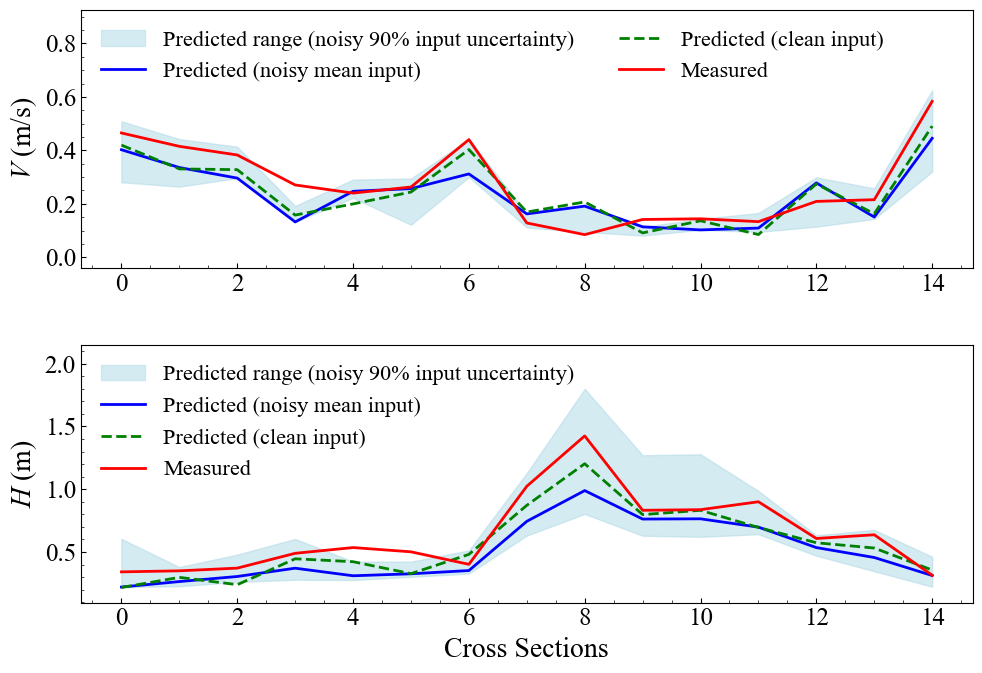

{'Q': {'MSE': np.float64(0.18026366185419626), 'R²': 0.0}, 'V': {'MSE': np.float64(0.004362054927653727), 'R²': 0.7900175691891481}, 'H': {'MSE': np.float64(0.014427244322285305), 'R²': 0.8419001073430152}}
{'Q_noisy': {'MSE': np.float64(0.19123299837853353), 'R²': 0.0}, 'V': {'MSE': np.float64(0.00647041618538491), 'R²': 0.6885243901099132}, 'H': {'MSE': np.float64(0.032071136475833886), 'R²': 0.6485508167083096}}


In [ ]:
idx ,idx_error= [],[]
for i,(hl,hr) in enumerate(zip(H_predl,H_predr)):
    if np.abs(hl - hr) < abs(min(hl, hr)) and hl > 0 and hr > 0:
        idx.append(i)
    else :
        idx_error.append(i)

plt.rcParams.update({
        'font.family':        'serif',
        'font.serif':         ['Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset':   'stix',          # STIX matches Times in math mode
        'font.size':          18,
        'axes.linewidth':     0.8,
        'axes.labelsize':     18,
        'xtick.labelsize':    18,
        'ytick.labelsize':    18,
        'xtick.direction':    'in',
        'ytick.direction':    'in',
        'xtick.major.width':  0.8,
        'ytick.major.width':  0.8,
        'xtick.minor.visible': True,
        'ytick.minor.visible': True,
        'xtick.minor.width':  0.5,
        'ytick.minor.width':  0.5,
        'axes.unicode_minus': False,
    })
# ========== New: Noiseless prediction (add_uncertainty=False) ==========
data_iter_nonoise = load_array(
    genFeaturesAndB(data_set, num_points=50, alpha=0.8,
                    add_uncertainty=False),   # Disable noise
    batch_size=1, is_train=False
)
# Use the same model
net_nn = ResNetGELU(in_channels=b)
net_nn = torch.load(trainName, weights_only=False)
net_nn.eval()
net_nn.cuda()

Ql_nn, Vl_nn, Hl_nn = realprediction(data_iter_nonoise, net_nn, cuda=True, l=1)
Qr_nn, Vr_nn, Hr_nn = realprediction(data_iter_nonoise, net_nn, cuda=True, r=1)

# Left-right bank fusion (identical fusion method as before)
Q_nn = [Ql_nn[i] + Qr_nn[i] for i in range(len(Ql_nn))]
V_nn = [(bl[i] * Vl_nn[i] + br[i] * Vr_nn[i]) / (br[i]+bl[i]) for i in range(len(Vl_nn))]
H_nn = [(bl[i] * Hl_nn[i] + br[i] * Hr_nn[i]) / (br[i]+bl[i]) for i in range(len(Hl_nn))]
# New: Filter noiseless prediction results
V_nn_sel = [V_nn[i] for i in idx]
H_nn_sel = [H_nn[i] for i in idx]
Q_nn_sel = [Q_nn[i] for i in idx]   # Can add if Q plot is needed
def plot_envelope_confidence(Q_mean, Q_lower, Q_upper,
                             V_mean, V_lower, V_upper,
                             H_mean, H_lower, H_upper,
                             Qx, Vx, Hx,
                             V_nn=None, H_nn=None):   # New noiseless parameters
    """
    Plot mean lines (blue), noiseless prediction lines (green dashed), measured values (red),
    and an envelope shaded area formed by the min/max of lower/mean/upper predictions.
    """
    plt.rcParams.update({'font.size': 18})
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.rm'] = 'Times New Roman'
    plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
    plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'

    fig = plt.figure(figsize=(10.3, 8))
    plt.subplots_adjust(top=0.85)

    x = np.arange(len(V_mean))

    # ---------- Velocity V ----------
    ax1 = plt.subplot(2, 1, 1)
    V_env_lower = [min(vl, vm, vu) for vl, vm, vu in zip(V_lower, V_mean, V_upper)]
    V_env_upper = [max(vl, vm, vu) for vl, vm, vu in zip(V_lower, V_mean, V_upper)]
    ax1.fill_between(x, V_env_lower, V_env_upper, color='lightblue', alpha=0.5,
                     label='Predicted range (noisy 90% input uncertainty)')
    ax1.plot(x, V_mean, label='Predicted (noisy mean input)', color='blue', linewidth=2)
    if V_nn is not None:
        ax1.plot(x, V_nn, label='Predicted (clean input)', color='green',
                 linestyle='--', linewidth=2)
    ax1.plot(x, Vx, label='Measured', color='red', linewidth=2)
    ax1.set_ylabel(r'$V$ (m/s)', fontsize=20)
    y_min = min(min(V_env_lower), min(Vx))
    y_max = max(max(V_env_upper), max(Vx))
    if V_nn is not None:
        y_min = min(y_min, min(V_nn))
        y_max = max(y_max, max(V_nn))
    ax1.set_ylim(y_min - 0.12, y_max + 0.3)
    ax1.legend(loc='upper left', ncol=2, frameon=False, fontsize=16)

    # ---------- Water depth H ----------
    ax2 = plt.subplot(2, 1, 2)
    H_env_lower = [min(hl, hm, hu) for hl, hm, hu in zip(H_lower, H_mean, H_upper)]
    H_env_upper = [max(hl, hm, hu) for hl, hm, hu in zip(H_lower, H_mean, H_upper)]
    ax2.fill_between(x, H_env_lower, H_env_upper, color='lightblue', alpha=0.5,
                     label='Predicted range (noisy 90% input uncertainty)')
    ax2.plot(x, H_mean, label='Predicted (noisy mean input)', color='blue', linewidth=2)
    if H_nn is not None:
        ax2.plot(x, H_nn, label='Predicted (clean input)', color='green',
                 linestyle='--', linewidth=2)
    ax2.plot(x, Hx, label='Measured', color='red', linewidth=2)
    ax2.set_xlabel('Cross Sections', fontsize=20)
    ax2.set_ylabel(r'$H$ (m)', fontsize=20)
    y_min = min(min(H_env_lower), min(Hx))
    y_max = max(max(H_env_upper), max(Hx))
    if H_nn is not None:
        y_min = min(y_min, min(H_nn))
        y_max = max(y_max, max(H_nn))
    ax2.set_ylim(y_min - 0.12, y_max + 0.35)
    ax2.legend(loc='upper left', frameon=False, fontsize=16)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, top=0.85)
    plt.show()

# ---- Existing noisy prediction valid indices ----
idx_noisy = idx   # Your existing idx, length 17

# ---- Filter valid cross sections separately for noiseless predictions ----
# Need noiseless left and right water depths Hl_nn, Hr_nn (should be computed in advance)
idx_nonoise = []
for i, (hl, hr) in enumerate(zip(Hl_nn, Hr_nn)):
    if hl > 0 and hr > 0 and np.abs(hl - hr) < np.abs(min(hl, hr)):
        idx_nonoise.append(i)

# ---- Take intersection ----
idx_common = sorted(list(set(idx_noisy) & set(idx_nonoise)))
print(f"Number of valid cross sections with noise: {len(idx_noisy)}")
print(f"Number of valid cross sections without noise: {len(idx_nonoise)}")
print(f"Number of intersection cross sections: {len(idx_common)}")

# ---- Filter all data using the intersection indices ----
# Noisy predictions
Qp_common      = [Q_mean[i] for i in idx_common]
Q_lower_common = [Q_lower[i] for i in idx_common]
Q_upper_common = [Q_upper[i] for i in idx_common]
Vp_common      = [V_mean[i] for i in idx_common]
V_lower_common = [V_lower[i] for i in idx_common]
V_upper_common = [V_upper[i] for i in idx_common]
Hp_common      = [H_mean[i] for i in idx_common]
H_lower_common = [H_lower[i] for i in idx_common]
H_upper_common = [H_upper[i] for i in idx_common]

# Measured values
Qr_common = [Qx[i] for i in idx_common]
Vr_common = [Vx[i] for i in idx_common]
Hr_common = [Hx[i] for i in idx_common]

# Noiseless predictions
V_nn_common = [V_nn[i] for i in idx_common]
H_nn_common = [H_nn[i] for i in idx_common]
Q_nn_common = [Q_nn[i] for i in idx_common]   # If needed

print (idx_common)

# ---- Call plotting function ----
plot_envelope_confidence(
    Qp_common, Q_lower_common, Q_upper_common,
    Vp_common, V_lower_common, V_upper_common,
    Hp_common, H_lower_common, H_upper_common,
    Qr_common, Vr_common, Hr_common,
    V_nn=V_nn_common, H_nn=H_nn_common
)
from sklearn.metrics import mean_squared_error, r2_score
metrics, metrics_noisy = {},{}
for name, pred, true in [('Q', Q_nn_common, Qr_common), ('V', V_nn_common, Vr_common), ('H', H_nn_common, Hr_common)]:
    mse = mean_squared_error(true, pred)
    r2 = r2_score(true, pred)
    metrics[name] = {'MSE': mse, 'R²': r2}
for name, pred, true in [('Q_noisy', Qp_common, Qr_common), ('V', Vp_common, Vr_common), ('H', Hp_common, Hr_common)]:
    mse = mean_squared_error(true, pred)
    r2 = r2_score(true, pred)
    metrics_noisy[name] = {'MSE': mse, 'R²': r2}
print(metrics)
print(metrics_noisy)